In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def show_image(img, title="Preview", show_axis=True):
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(title)
    if show_axis:
        plt.axis('on')
    else:
        plt.axis('off')
    plt.show()

def apply_image_filter(img, filter_type):
    if filter_type == "bw":
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    elif filter_type == "red":
        red_img = img.copy()
        red_img[:, :, 1] = 0
        red_img[:, :, 2] = 0
        return red_img
    elif filter_type == "blue":
        blue_img = img.copy()
        blue_img[:, :, 0] = 0
        blue_img[:, :, 1] = 0
        return blue_img
    elif filter_type == "green":
        green_img = img.copy()
        green_img[:, :, 0] = 0
        green_img[:, :, 2] = 0
        return green_img
    return img

def apply_video_filter(frame, filter_type):
    if filter_type == "gray":
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    elif filter_type == "red":
        frame[:, :, 0] = 0  
        frame[:, :, 1] = 0  
        return frame
    elif filter_type == "blue":
        frame[:, :, 1] = 0  
        frame[:, :, 2] = 0  
        return frame
    elif filter_type == "green":
        frame[:, :, 0] = 0  
        frame[:, :, 2] = 0  
        return frame
    return frame

print("Media Processing Studio Initialized Successfully!")

Media Processing Studio Initialized Successfully!


In [2]:
print("--- Select Media Type ---")
print("1. Image Processing Pipeline")
print("2. Video Processing Pipeline")
choice = input("Enter choice (1 or 2): ").strip()

--- Select Media Type ---
1. Image Processing Pipeline
2. Video Processing Pipeline


Enter choice (1 or 2):  1


Enter image filename (e.g., photo.jpg):  specs.png


Current Image Size: Width = 666px, Height = 375px


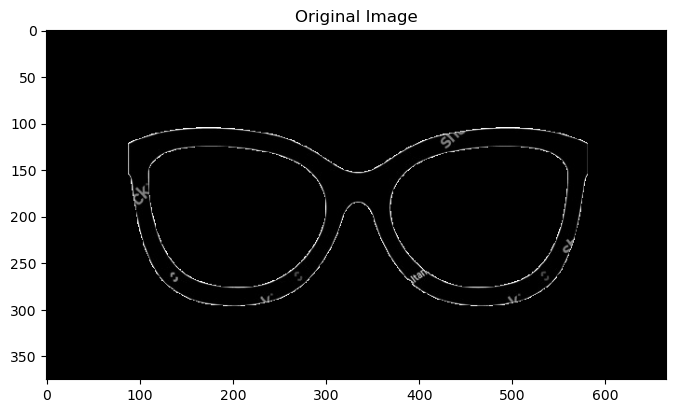

Enter new width and height separated by space (or press Enter to skip):  400 300


Resized to: 400x300


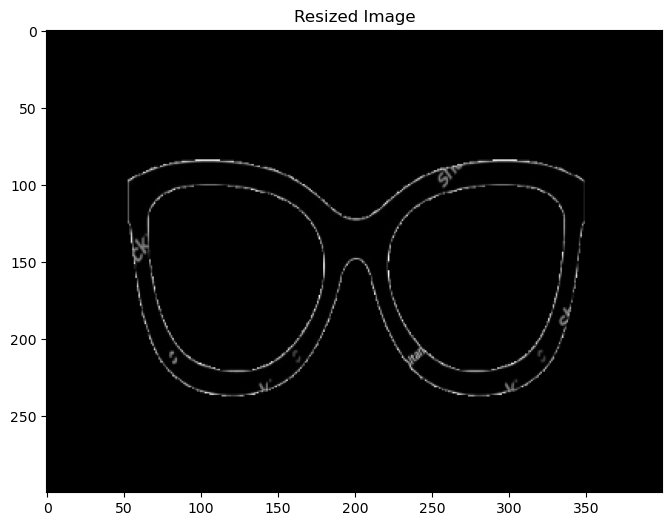

Enter rotation angle in degrees (or press Enter to skip):  45


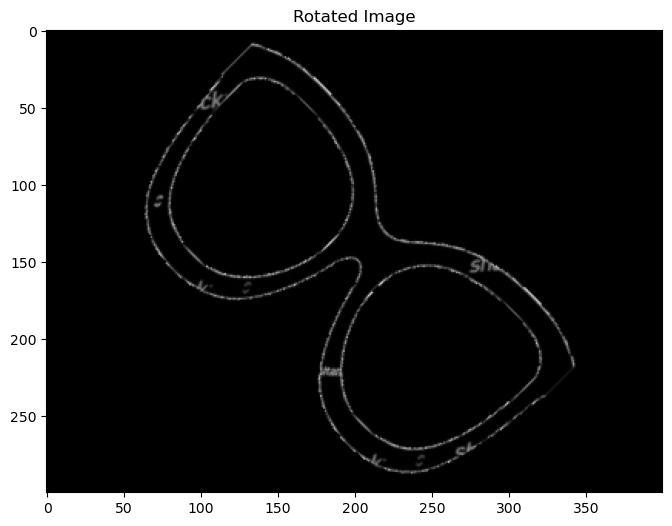


Available Filters: bw (Black & White), red, blue, green, normal


Choose a filter type (or press Enter to skip):  blue


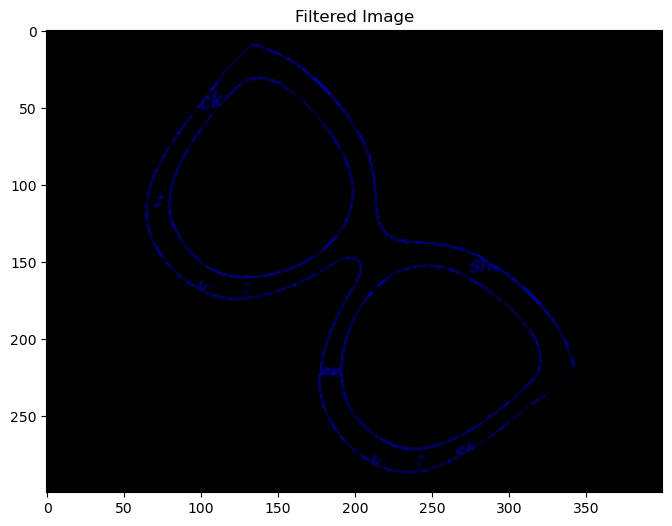

Enter filename to download your image (e.g., output.png):  taskresult.png'


Success! Saved as taskresult.png'


In [3]:
if choice == "1":
    img_path = input("Enter image filename (e.g., photo.jpg): ")
    img = cv2.imread(img_path)
    
    if img is None:
        print("Error: Image file not found.")
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img_rgb.shape
        print(f"Current Image Size: Width = {w}px, Height = {h}px")
        show_image(img_rgb, "Original Image")
        
        resize_input = input("Enter new width and height separated by space (or press Enter to skip): ").strip()
        if resize_input:
            new_w, new_h = map(int, resize_input.split())
            img_rgb = cv2.resize(img_rgb, (new_w, new_h))
            h, w, _ = img_rgb.shape
            print(f"Resized to: {w}x{h}")
            show_image(img_rgb, "Resized Image")
            
        rot_input = input("Enter rotation angle in degrees (or press Enter to skip): ").strip()
        if rot_input:
            angle = float(rot_input)
            center = (w // 2, h // 2)
            matrix = cv2.getRotationMatrix2D(center, -angle, 1.0)
            img_rgb = cv2.warpAffine(img_rgb, matrix, (w, h))
            show_image(img_rgb, "Rotated Image")
            
        print("\nAvailable Filters: bw (Black & White), red, blue, green, normal")
        filt_input = input("Choose a filter type (or press Enter to skip): ").strip().lower()
        if filt_input and filt_input != "normal":
            img_rgb = apply_image_filter(img_rgb, filt_input)
            show_image(img_rgb, "Filtered Image")
            
        out_name = input("Enter filename to download your image (e.g., output.png): ")
        final_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        cv2.imwrite(out_name, final_bgr)
        print(f"Success! Saved as {out_name}")
else:
    print("Skipping Image pipeline. Run this cell only if you chose Option 1.")

In [5]:
if choice == "2":
    vid_path = input("Enter video filename (e.g., video.mp4): ")
    cap = cv2.VideoCapture(vid_path)
    
    if not cap.isOpened():
        print("Error: Video file not found.")
    else:
        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        vid_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        vid_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        duration = total_frames / fps
        
        print(f"Video Loaded! Resolution: {vid_w}x{vid_h} | Total Duration: {duration:.2f} seconds")
        
        start_t = float(input(f"Enter start timestamp in seconds (0 to {duration}): "))
        end_t = float(input(f"Enter end timestamp in seconds ({start_t} to {duration}): "))
        
        print("\nAvailable Filters: red, blue, green, gray, normal")
        v_filter = input("Choose a video filter: ").strip().lower()
        
        print(f"\nVideo resolution limits are: Width (0 to {vid_w}), Height (0 to {vid_h})")
        ymin = int(input("Enter top crop boundary (ymin): "))
        ymax = int(input("Enter bottom crop boundary (ymax): "))
        xmin = int(input("Enter left crop boundary (xmin): "))
        xmax = int(input("Enter right crop boundary (xmax): "))
        
        out_vid_name = input("\nEnter output video filename to download (e.g., final_video.mp4): ")
        
        crop_w = xmax - xmin
        crop_h = ymax - ymin
        
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out_writer = cv2.VideoWriter(out_vid_name, fourcc, fps, (crop_w, crop_h))
        
        start_frame = int(start_t * fps)
        end_frame = int(end_t * fps)
        
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        current_frame_idx = start_frame
        
        print("\nProcessing video frames... Please wait.")
        while current_frame_idx <= end_frame:
            ret, frame = cap.read()
            if not ret:
                break
                
            cropped_frame = frame[ymin:ymax, xmin:xmax]
            processed_frame = apply_video_filter(cropped_frame, v_filter)
            out_writer.write(processed_frame)
            current_frame_idx += 1
            
        cap.release()
        out_writer.release()
        print(f"🎉 Process Complete! Video downloaded safely as '{out_vid_name}'")
else:
    print("Skipping Video pipeline. Run this cell only if you chose Option 2.")

Skipping Video pipeline. Run this cell only if you chose Option 2.
